<a href="https://colab.research.google.com/github/Emil-888/Data-Science/blob/feature%2Fmodelo-ml/Modelo_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [14]:
# Cargar y visualizar las primeras filas del dataset

df = pd.read_csv('/content/energias-alternativas.csv', encoding='latin-1')
df.head()


,sector_id,sector_nombre,variable_id,actividad_producto_nombre,indicador,unidad_de_medida,fuente,frecuencia_nombre,cobertura_nombre,alcance_tipo,alcance_id,alcance_nombre,indice_tiempo,valor
0,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-01-01,0.000
1,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-02-01,0.000
2,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-03-01,0.000
3,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-04-01,0.000
4,25,Energías alternativas,440,Energía biogás,Generación,MWh,CAMMESA,Mensual,Nacional,PROVINCIA,6,BUENOS AIRES,2012-05-01,764.924


**Diagnóstico Inicial**

Operaciones iniciales: head(), info(), describe(), valores faltantes, duplicados y nombres de columnas.

In [15]:
df.info() # nos muestra cantidad de filas, columnas y nombres, cantidad de valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5311 entries, 0 to 5310
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   sector_id                  5311 non-null   int64  
 1   sector_nombre              5311 non-null   object 
 2   variable_id                5311 non-null   int64  
 3   actividad_producto_nombre  5311 non-null   object 
 4   indicador                  5311 non-null   object 
 5   unidad_de_medida           5311 non-null   object 
 6   fuente                     5311 non-null   object 
 7   frecuencia_nombre          5311 non-null   object 
 8   cobertura_nombre           5311 non-null   object 
 9   alcance_tipo               5311 non-null   object 
 10  alcance_id                 5311 non-null   int64  
 11  alcance_nombre             5311 non-null   object 
 12  indice_tiempo              5311 non-null   object 
 13  valor                      5311 non-null   float

In [16]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sector_id,5311.0,NaN,NaN,NaN,25.0,0.0,25.0,25.0,25.0,25.0,25.0
sector_nombre,5311,1,Energías alternativas,5311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
variable_id,5311.0,NaN,NaN,NaN,445.452834,2.844691,440.0,443.0,447.0,448.0,450.0
actividad_producto_nombre,5311,6,Energía pah,2172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicador,5311,2,Generación,3072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unidad_de_medida,5311,2,MWh,3072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuente,5311,1,CAMMESA,5311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
frecuencia_nombre,5311,1,Mensual,5311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cobertura_nombre,5311,1,Nacional,5311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alcance_tipo,5311,1,PROVINCIA,5311,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
df.tail()

,sector_id,sector_nombre,variable_id,actividad_producto_nombre,indicador,unidad_de_medida,fuente,frecuencia_nombre,cobertura_nombre,alcance_tipo,alcance_id,alcance_nombre,indice_tiempo,valor
5306,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-08-01,61.2
5307,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-09-01,61.2
5308,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-10-01,61.2
5309,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-11-01,61.2
5310,25,Energías alternativas,450,Energía solar,Potencia instalada,MW,CAMMESA,Mensual,Nacional,PROVINCIA,74,SAN LUIS,2020-12-01,61.2


In [19]:
df.describe

<bound method NDFrame.describe of       sector_id          sector_nombre  variable_id actividad_producto_nombre  \
0            25  Energías alternativas          440            Energía biogás   
1            25  Energías alternativas          440            Energía biogás   
2            25  Energías alternativas          440            Energía biogás   
3            25  Energías alternativas          440            Energía biogás   
4            25  Energías alternativas          440            Energía biogás   
...         ...                    ...          ...                       ...   
5306         25  Energías alternativas          450             Energía solar   
5307         25  Energías alternativas          450             Energía solar   
5308         25  Energías alternativas          450             Energía solar   
5309         25  Energías alternativas          450             Energía solar   
5310         25  Energías alternativas          450             Energía solar   

               indicador unidad_de_medida   fuente frecuencia_nombre  \
0             Generación              MWh  CAMMESA           Mensual   
1             Generación              MWh  CAMMESA           Mensual   
2             Generación              MWh  CAMMESA           Mensual   
3             Generación              MWh  CAMMESA           Mensual   
4             Generación              MWh  CAMMESA           Mensual   
...                  ...              ...      ...               ...   
5306  Potencia instalada               MW  CAMMESA           Mensual   
5307  Potencia instalada               MW  CAMMESA           Mensual   
5308  Potencia instalada               MW  CAMMESA           Mensual   
5309  Potencia instalada               MW  CAMMESA           Mensual   
5310  Potencia instalada               MW  CAMMESA           Mensual   

     cobertura_nombre alcance_tipo  alcance_id alcance_nombre indice_tiempo  \
0            Nacional    PROVINCIA           6   BUENOS AIRES    2012-01-01   
1            Nacional    PROVINCIA           6   BUENOS AIRES    2012-02-01   
2            Nacional    PROVINCIA           6   BUENOS AIRES    2012-03-01   
3            Nacional    PROVINCIA           6   BUENOS AIRES    2012-04-01   
4            Nacional    PROVINCIA           6   BUENOS AIRES    2012-05-01   
...               ...          ...         ...            ...           ...   
5306         Nacional    PROVINCIA          74       SAN LUIS    2020-08-01   
5307         Nacional    PROVINCIA          74       SAN LUIS    2020-09-01   
5308         Nacional    PROVINCIA          74       SAN LUIS    2020-10-01   
5309         Nacional    PROVINCIA          74       SAN LUIS    2020-11-01   
5310         Nacional    PROVINCIA          74       SAN LUIS    2020-12-01   

        valor  
0       0.000  
1       0.000  
2       0.000  
3       0.000  
4     764.924  
...       ...  
5306   61.200  
5307   61.200  
5308   61.200  
5309   61.200  
5310   61.200  

[5311 rows x 14 columns]>

In [18]:
df.columns

Index(['sector_id', 'sector_nombre', 'variable_id',
       'actividad_producto_nombre', 'indicador', 'unidad_de_medida', 'fuente',
       'frecuencia_nombre', 'cobertura_nombre', 'alcance_tipo', 'alcance_id',
       'alcance_nombre', 'indice_tiempo', 'valor'],
      dtype='object')

In [21]:
df.dtypes

,0
sector_id,int64
sector_nombre,object
variable_id,int64
actividad_producto_nombre,object
indicador,object
unidad_de_medida,object
fuente,object
frecuencia_nombre,object
cobertura_nombre,object
alcance_tipo,object


In [22]:
# Columnas que no aportan (son constantes: 1 valor único)
df = df.drop(columns=['sector_id', 'sector_nombre', 'fuente',
                       'frecuencia_nombre', 'cobertura_nombre', 'alcance_tipo'])

# Convertir fecha
df['indice_tiempo'] = pd.to_datetime(df['indice_tiempo'])
df['año'] = df['indice_tiempo'].dt.year
df['mes'] = df['indice_tiempo'].dt.month

# Renombrar para trabajar más cómodo
df = df.rename(columns={
    'actividad_producto_nombre': 'tipo_energia',
    'alcance_nombre': 'provincia',
    'indicador': 'indicador',
    'valor': 'valor'
})

# Duplicados
df.duplicated().sum()
df = df.drop_duplicates()

# Chequeo de valores negativos o inconsistentes
(df['valor'] < 0).sum()

np.int64(0)

In [25]:
# Separar en dos datasets (Generación vs Potencia)
df_generacion = df[df['indicador'] == 'Generación'].copy()
df_potencia = df[df['indicador'] == 'Potencia instalada'].copy()

In [26]:
# EDA Exploración General
df_generacion.describe()

# Evolución total de generación por año y tipo de energía
gen_anual = df_generacion.groupby(['año', 'tipo_energia'])['valor'].sum().reset_index()
gen_anual.head()

# Ranking de tipos de energía por generación total
df_generacion.groupby('tipo_energia')['valor'].sum().sort_values(ascending=False)

# Ranking de provincias
df_generacion.groupby('provincia')['valor'].sum().sort_values(ascending=False)

,valor
provincia,
BUENOS AIRES,5.230768e+07
CORDOBA,2.532345e+07
CHUBUT,1.063011e+07
SAN JUAN,3.897946e+06
MENDOZA,2.097724e+06
TUCUMAN,1.785225e+06
SALTA,1.752194e+06
RIO NEGRO,1.528556e+06
SANTIAGO DEL ESTERO,1.417064e+06


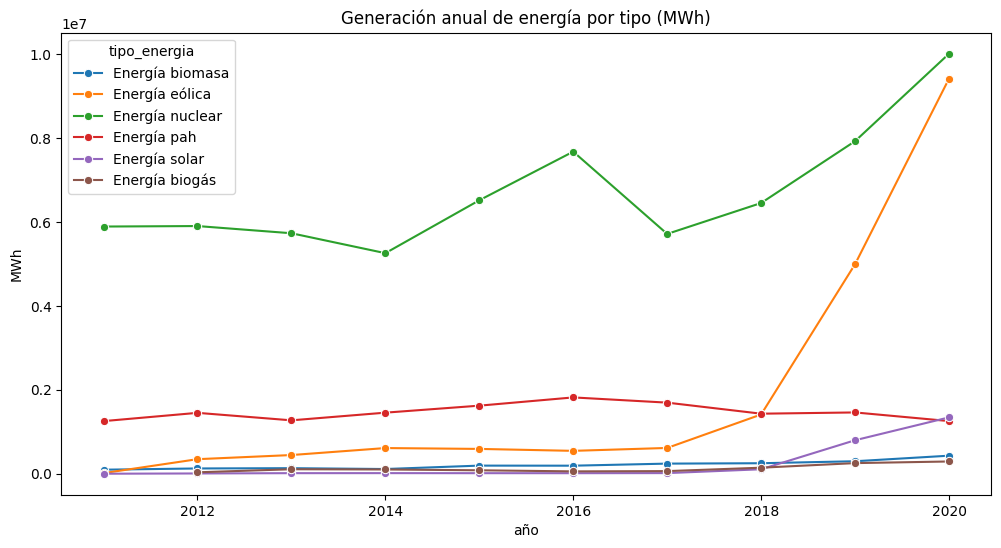

In [27]:
# Visualización — evolución temporal
plt.figure(figsize=(12,6))
sns.lineplot(data=gen_anual, x='año', y='valor', hue='tipo_energia', marker='o')
plt.title('Generación anual de energía por tipo (MWh)')
plt.ylabel('MWh')
plt.show()

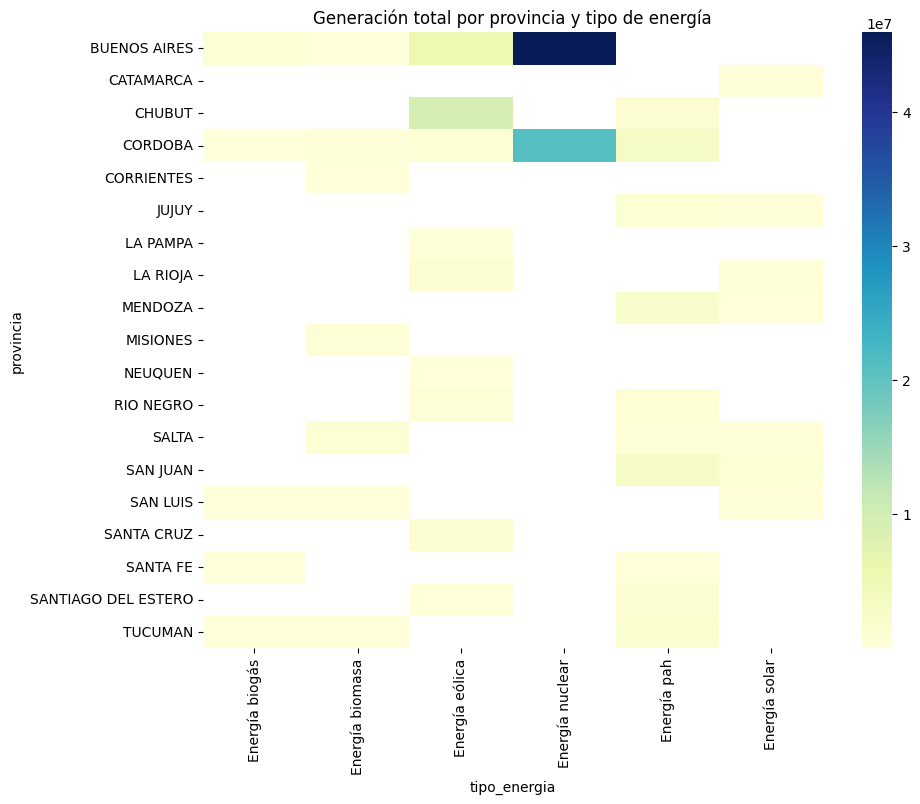

In [28]:
# Mapa de calor: provincia x tipo de energía
pivot = df_generacion.pivot_table(index='provincia', columns='tipo_energia',
                                    values='valor', aggfunc='sum')
plt.figure(figsize=(10,8))
sns.heatmap(pivot, cmap='YlGnBu', annot=False)
plt.title('Generación total por provincia y tipo de energía')
plt.show()

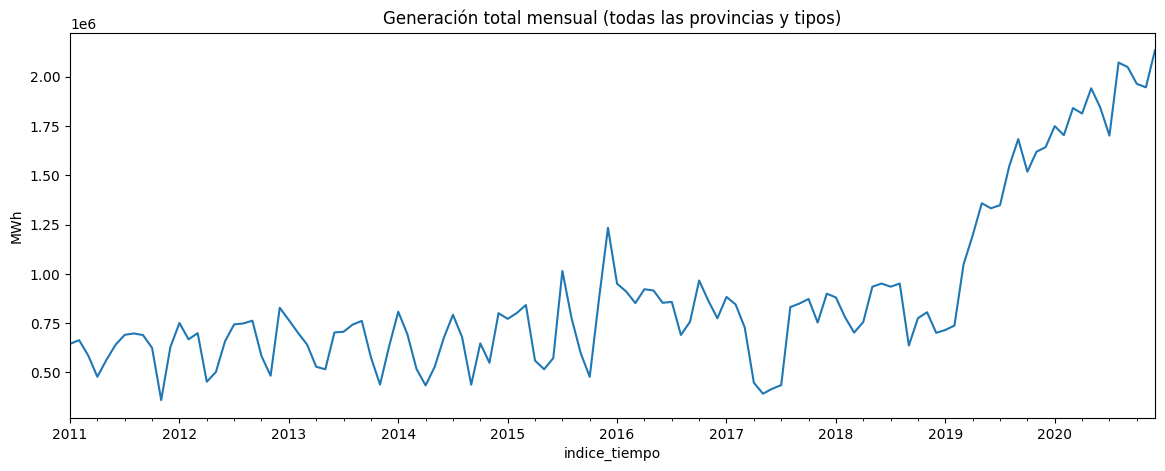

In [30]:
# Series temporales
serie_mensual = df_generacion.groupby('indice_tiempo')['valor'].sum()

plt.figure(figsize=(14,5))
serie_mensual.plot()
plt.title('Generación total mensual (todas las provincias y tipos)')
plt.ylabel('MWh')
plt.show()

In [31]:
# Correlación
merged = pd.merge(
    df_generacion.groupby(['provincia','tipo_energia','año'])['valor'].sum().reset_index().rename(columns={'valor':'generacion'}),
    df_potencia.groupby(['provincia','tipo_energia','año'])['valor'].sum().reset_index().rename(columns={'valor':'potencia'}),
    on=['provincia','tipo_energia','año'], how='inner'
)
merged.corr(numeric_only=True)

,año,generacion,potencia
año,1.000000,0.031960,0.053495
generacion,0.031960,1.000000,0.897073
potencia,0.053495,0.897073,1.000000
